In [1]:
#   1. IV Surface    — Market vs Heston vs SABR (3D + 2D heatmap)
#   2. Model Smiles  — Per-expiry overlay: all models vs market
#   3. Greeks Surface — Delta and Gamma as functions of S and T
#   4. Convergence   — Binomial → BS and MC confidence intervals
#
# This notebook is self-contained — loads all saved outputs from
# Phases 1-6 and produces publication-quality plots.
# Designed to be the single demo file on your GitHub.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm
from scipy.optimize import brentq
from scipy.integrate import quad
import warnings, os, glob, math, json
warnings.filterwarnings("ignore")

# ── Plot style ──
plt.rcParams.update({
    "figure.dpi"      : 130,
    "axes.spines.top" : False,
    "axes.spines.right": False,
    "axes.grid"       : True,
    "grid.alpha"      : 0.3,
    "font.size"       : 10,
})

BLUE   = "#2563EB"
RED    = "#DC2626"
GREEN  = "#059669"
PURPLE = "#7C3AED"
AMBER  = "#D97706"
BLACK  = "#111827"

print("Imports OK ✓")

Imports OK ✓


In [ ]:
def load_options_data(ticker="SPY", data_dir="data"):
    files    = sorted(glob.glob(f"{data_dir}/{ticker}_options_*.csv"))
    latest   = files[-1]
    date_str = latest.split("_options_")[1].replace(".csv","")
    meta     = pd.read_csv(f"{data_dir}/{ticker}_meta_{date_str}.csv",
                           header=None, index_col=0).squeeze()
    df = pd.read_csv(latest)
    return df, float(meta["spot"]), float(meta["r"]), float(meta["q"]), date_str

df, S, r, q, snapshot_date = load_options_data("SPY")
cal_df = df[
    (df["option_type"] == "call") &
    (df["iv"].notna()) &
    (df["iv"] >= 0.05) & (df["iv"] <= 1.50) &
    (df["spread_pct"] <= 0.30)
].copy()
print(f"Market data loaded: {len(cal_df)} contracts, snapshot {snapshot_date}")

# ── Calibrated parameters ──
with open("data/calibrated_params.json") as f:
    params = json.load(f)

kappa_h = params["heston"]["kappa"]
theta_h = params["heston"]["theta"]
xi_h    = params["heston"]["xi"]
rho_h   = params["heston"]["rho"]
v0_h    = params["heston"]["v0"]

sigma_m   = params["merton"]["sigma"]
lam_m     = params["merton"]["lam"]
mu_j_m    = params["merton"]["mu_j"]
sigma_j_m = params["merton"]["sigma_j"]

sabr_cal = params["sabr"]   # {expiry: {alpha, nu, rho, rmse, T}}

print(f"Heston : κ={kappa_h}, θ={theta_h}, ξ={xi_h}, ρ={rho_h}, v0={v0_h}")
print(f"Merton : σ={sigma_m}, λ={lam_m}, μ_j={mu_j_m}, σ_j={sigma_j_m}")
print(f"SABR   : {len(sabr_cal)} expiry slices calibrated")

Market data loaded: 960 contracts, snapshot 2026-03-27
Heston : κ=4.862, θ=0.041, ξ=0.629, ρ=-0.934, v0=0.075
Merton : σ=0.21349443017164538, λ=0.5240073616986197, μ_j=-0.2594635999013165, σ_j=0.1
SABR   : 22 expiry slices calibrated


In [ ]:
def bs_price(S, K, T, r, sigma, q=0.0, option_type="call"):
    if T <= 0:
        return max(S-K,0) if option_type=="call" else max(K-S,0)
    d1 = (np.log(S/K) + (r-q+0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type=="call":
        return float(S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2))
    return float(K*np.exp(-r*T)*norm.cdf(-d2) - S*np.exp(-q*T)*norm.cdf(-d1))

def bs_greeks(S, K, T, r, sigma, q=0.0, option_type="call"):
    d1, d2 = (np.log(S/K)+(r-q+0.5*sigma**2)*T)/(sigma*np.sqrt(T)), 0
    d2 = d1 - sigma*np.sqrt(T)
    phi  = norm.pdf(d1)
    eqT  = np.exp(-q*T)
    erT  = np.exp(-r*T)
    sqT  = np.sqrt(T)
    delta = eqT*norm.cdf(d1) if option_type=="call" else eqT*(norm.cdf(d1)-1)
    gamma = phi*eqT / (S*sigma*sqT)
    vega  = S*eqT*phi*sqT / 100
    return {"delta": delta, "gamma": gamma, "vega": vega}

def compute_iv(price, S, K, T, r, q=0.0, option_type="call"):
    if price <= 0 or T <= 0:
        return np.nan
    try:
        return brentq(lambda s: bs_price(S,K,T,r,s,q,option_type)-price,
                      1e-4, 5.0, xtol=1e-5, maxiter=200)
    except:
        return np.nan

def heston_price_cf(S, K, T, r, q, kappa, theta, xi, rho, v0,
                    option_type="call", limit=200):
    i = complex(0,1)
    F = S*np.exp((r-q)*T)
    k = np.log(F/K)
    def cf(phi):
        d = np.sqrt((kappa-i*rho*xi*phi)**2 + xi**2*(phi**2+i*phi))
        A = kappa-i*rho*xi*phi
        g = (A-d)/(A+d)
        e = np.exp(-d*T)
        D = (1.0-e)/(1.0-g*e)
        C = kappa*theta/xi**2*((A-d)*T - 2*np.log((1-g*e)/(1-g)))
        return np.exp(C + (A-d)/xi**2*D*v0 + i*phi*k)
    res, _ = quad(lambda phi: np.real(cf(phi-0.5j)/(phi**2+0.25)),
                  0, limit, limit=500, epsabs=1e-8)
    call = S*np.exp(-q*T) - K*np.exp(-r*T)/np.pi*res
    return float(call) if option_type=="call" \
           else float(call) - S*np.exp(-q*T) + K*np.exp(-r*T)

def merton_price_series(S, K, T, r, sigma, q=0.0,
                        lam=0.5, mu_j=-0.1, sigma_j=0.15,
                        option_type="call", n_terms=50):
    m    = np.exp(mu_j+0.5*sigma_j**2)-1
    lam_ = lam*(1+m)
    price = 0.0
    for n in range(n_terms):
        w = np.exp(-lam_*T)*(lam_*T)**n/math.factorial(n)
        if w < 1e-15: break
        price += w*bs_price(S, K, T, r-lam*m+n*np.log(1+m)/T,
                             np.sqrt(sigma**2+n*sigma_j**2/T), q, option_type)
    return price

def sabr_iv(F, K, T, alpha, beta, nu, rho):
    if abs(F-K) < 1e-6:
        FK = F**(1-beta)
        return alpha/FK*(1+(((1-beta)**2/24*alpha**2/FK**2
               + rho*beta*nu*alpha/(4*FK)
               + (2-3*rho**2)/24*nu**2)*T))
    log_FK = np.log(F/K)
    FK_mid = np.sqrt(F*K)
    z = nu/alpha*FK_mid**(1-beta)*log_FK
    x = np.log((np.sqrt(1-2*rho*z+z**2)+z-rho)/(1-rho))
    num = alpha
    den = FK_mid**(1-beta)*(1+(1-beta)**2/24*log_FK**2
                              +(1-beta)**4/1920*log_FK**4)
    cor = ((1-beta)**2/24*alpha**2/FK_mid**(2*(1-beta))
           + rho*beta*nu*alpha/(4*FK_mid**(1-beta))
           + (2-3*rho**2)/24*nu**2)
    return num/den*(z/x)*(1+cor*T)

def binomial_tree(S, K, T, r, sigma, q=0.0, N=200,
                  option_type="call", exercise="european"):
    dt = T/N; u = np.exp(sigma*np.sqrt(dt)); d = 1/u
    p  = (np.exp((r-q)*dt)-d)/(u-d)
    j  = np.arange(N+1)
    V  = np.maximum(S*u**(2*j-N)-K,0) if option_type=="call" \
         else np.maximum(K-S*u**(2*j-N),0)
    for i in range(N-1,-1,-1):
        V = np.exp(-r*dt)*(p*V[1:]+(1-p)*V[:-1])
        if exercise=="american":
            Si = S*u**(2*np.arange(i+1)-i)
            V  = np.maximum(V, np.maximum(Si-K,0) if option_type=="call"
                               else np.maximum(K-Si,0))
    return float(V[0])

print("Pricing functions loaded ✓")

Pricing functions loaded ✓


Building IV surfaces...


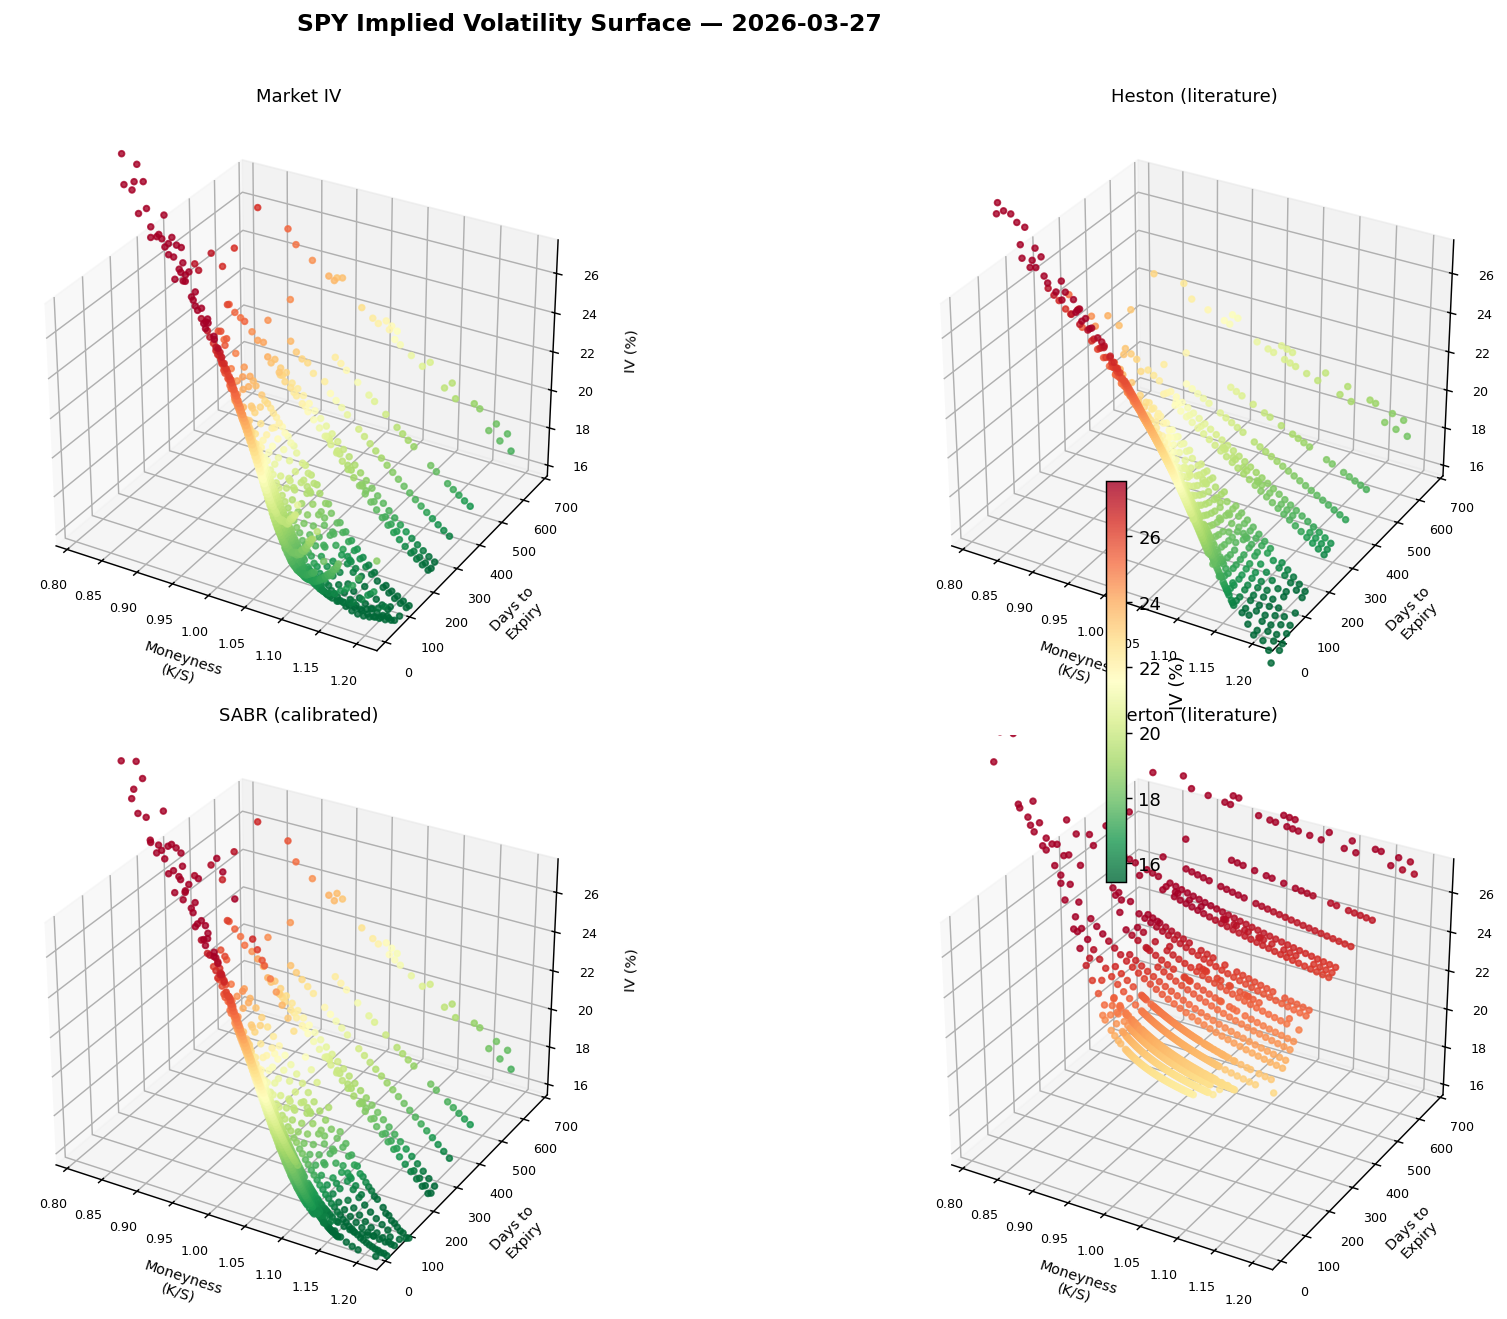

Plot 1 saved ✓


In [ ]:
# The centrepiece plot of the project.
# Three panels side by side:
#   Left  : Market IV surface (scatter of actual quotes)
#   Centre: Heston model surface (on same grid)
#   Right : SABR model surface  (calibrated per slice)
# Color scale is consistent across all three panels — easy visual comparison.
# -----------------------------------------------------------------------------

print("Building IV surfaces...")

# Compute model IVs for every contract in cal_df
heston_ivs, sabr_ivs, merton_ivs = [], [], []

for _, row in cal_df.iterrows():
    K, T_val, exp = row["strike"], row["T"], row["expiry"]

    # Heston
    try:
        hp = heston_price_cf(S, K, T_val, r, q,
                             kappa_h, theta_h, xi_h, rho_h, v0_h,
                             option_type="call")
        heston_ivs.append(compute_iv(hp, S, K, T_val, r, q))
    except:
        heston_ivs.append(np.nan)

    # SABR
    if exp in sabr_cal:
        p  = sabr_cal[exp]
        F  = S*np.exp((r-q)*T_val)
        try:
            sabr_ivs.append(sabr_iv(F, K, T_val,
                                    p["alpha"], 0.5, p["nu"], p["rho"]))
        except:
            sabr_ivs.append(np.nan)
    else:
        sabr_ivs.append(np.nan)

    # Merton
    try:
        mp = merton_price_series(S, K, T_val, r, sigma_m, q,
                                 lam_m, mu_j_m, sigma_j_m,
                                 option_type="call")
        merton_ivs.append(compute_iv(mp, S, K, T_val, r, q))
    except:
        merton_ivs.append(np.nan)

cal_df["iv_heston"] = heston_ivs
cal_df["iv_sabr"]   = sabr_ivs
cal_df["iv_merton"] = merton_ivs

# ── 3D surface plot ──
iv_min = cal_df["iv"].quantile(0.05) * 100
iv_max = cal_df["iv"].quantile(0.95) * 100

fig = plt.figure(figsize=(14,10))
fig.suptitle(f"SPY Implied Volatility Surface — {snapshot_date}",
             fontsize=13, fontweight="bold", y=1.01)

panels = [
    ("Market IV",           "iv",        "black"),
    ("Heston (literature)", "iv_heston", BLUE),
    ("SABR (calibrated)",   "iv_sabr",   GREEN),
    ("Merton (literature)", "iv_merton", RED),
]

for idx, (title, col, color) in enumerate(panels):
    ax  = fig.add_subplot(2, 2, idx+1, projection="3d")
    sub = cal_df.dropna(subset=[col])
    sc  = ax.scatter(
        sub["moneyness"], sub["T"]*365, sub[col]*100,
        c=sub[col]*100, cmap="RdYlGn_r",
        vmin=iv_min, vmax=iv_max,
        s=10, alpha=0.8
    )
    ax.set_xlabel("Moneyness\n(K/S)", labelpad=6, fontsize=8)
    ax.set_ylabel("Days to\nExpiry",  labelpad=6, fontsize=8)
    ax.set_zlabel("IV (%)",           labelpad=6, fontsize=8)
    ax.set_zlim(iv_min, iv_max)
    ax.set_title(title, fontsize=10, pad=8)
    ax.tick_params(labelsize=7)

plt.colorbar(sc, ax=fig.axes, shrink=0.4, pad=0.08, label="IV (%)")
plt.tight_layout()
plt.savefig("plot1_iv_surface.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 1 saved ✓")

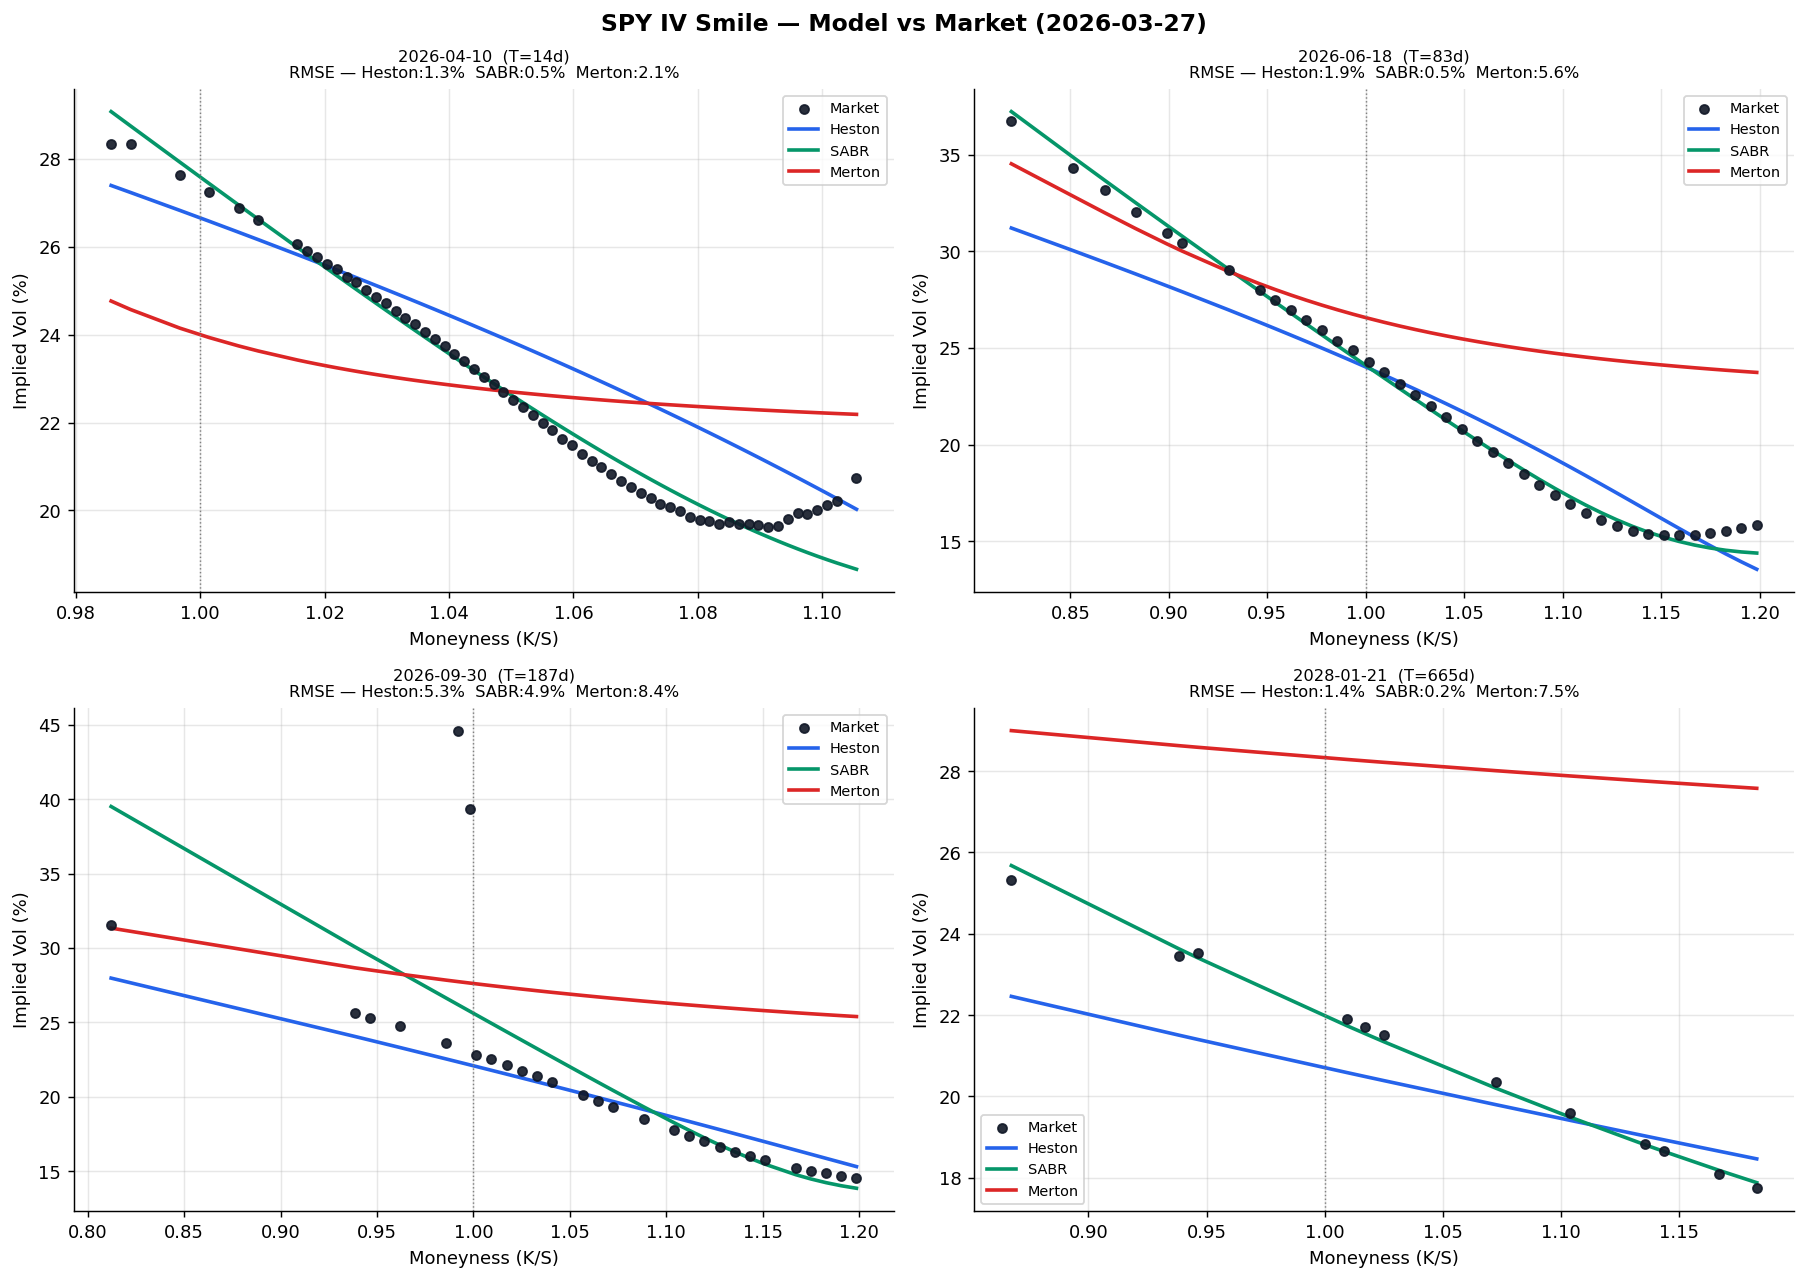

Plot 2 saved ✓


In [ ]:
# Four expiries chosen to span the term structure:
# short (2wk), medium (1mo, 3mo), long (6mo)
# Each panel shows all models vs market on the same axes.

expiries_all = sorted(cal_df["expiry"].unique())
n_exp        = len(expiries_all)

# Pick 4 expiries spread across term structure
idx_pick  = np.round(np.linspace(0, n_exp-1, min(4, n_exp))).astype(int)
exp_plot  = [expiries_all[i] for i in idx_pick]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"SPY IV Smile — Model vs Market ({snapshot_date})",
             fontsize=13, fontweight="bold")
axes = axes.flatten()

for i, exp in enumerate(exp_plot):
    ax  = axes[i]
    sub = cal_df[cal_df["expiry"] == exp].sort_values("moneyness")
    T_val = sub["T"].iloc[0]

    # Market
    ax.scatter(sub["moneyness"], sub["iv"]*100,
               s=25, color=BLACK, zorder=5, label="Market", alpha=0.9)

    # Models
    for col, color, label in [
        ("iv_heston", BLUE,   "Heston"),
        ("iv_sabr",   GREEN,  "SABR"),
        ("iv_merton", RED,    "Merton"),
    ]:
        clean = sub.dropna(subset=[col]).sort_values("moneyness")
        if len(clean) > 1:
            ax.plot(clean["moneyness"], clean[col]*100,
                    color=color, lw=2, label=label)

    # RMSE annotations
    rmse_h = np.sqrt(((sub["iv_heston"]-sub["iv"])**2).mean())*100
    rmse_s = np.sqrt(((sub["iv_sabr"]  -sub["iv"])**2).mean())*100
    rmse_m = np.sqrt(((sub["iv_merton"]-sub["iv"])**2).mean())*100
    ax.set_title(f"{exp}  (T={T_val*365:.0f}d)\n"
                 f"RMSE — Heston:{rmse_h:.1f}%  SABR:{rmse_s:.1f}%  "
                 f"Merton:{rmse_m:.1f}%", fontsize=9)

    ax.axvline(1.0, color="gray", ls=":", lw=0.8)
    ax.set_xlabel("Moneyness (K/S)")
    ax.set_ylabel("Implied Vol (%)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("plot2_smile_overlay.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 2 saved ✓")

ATM vol used for Greeks surface: 24.3%


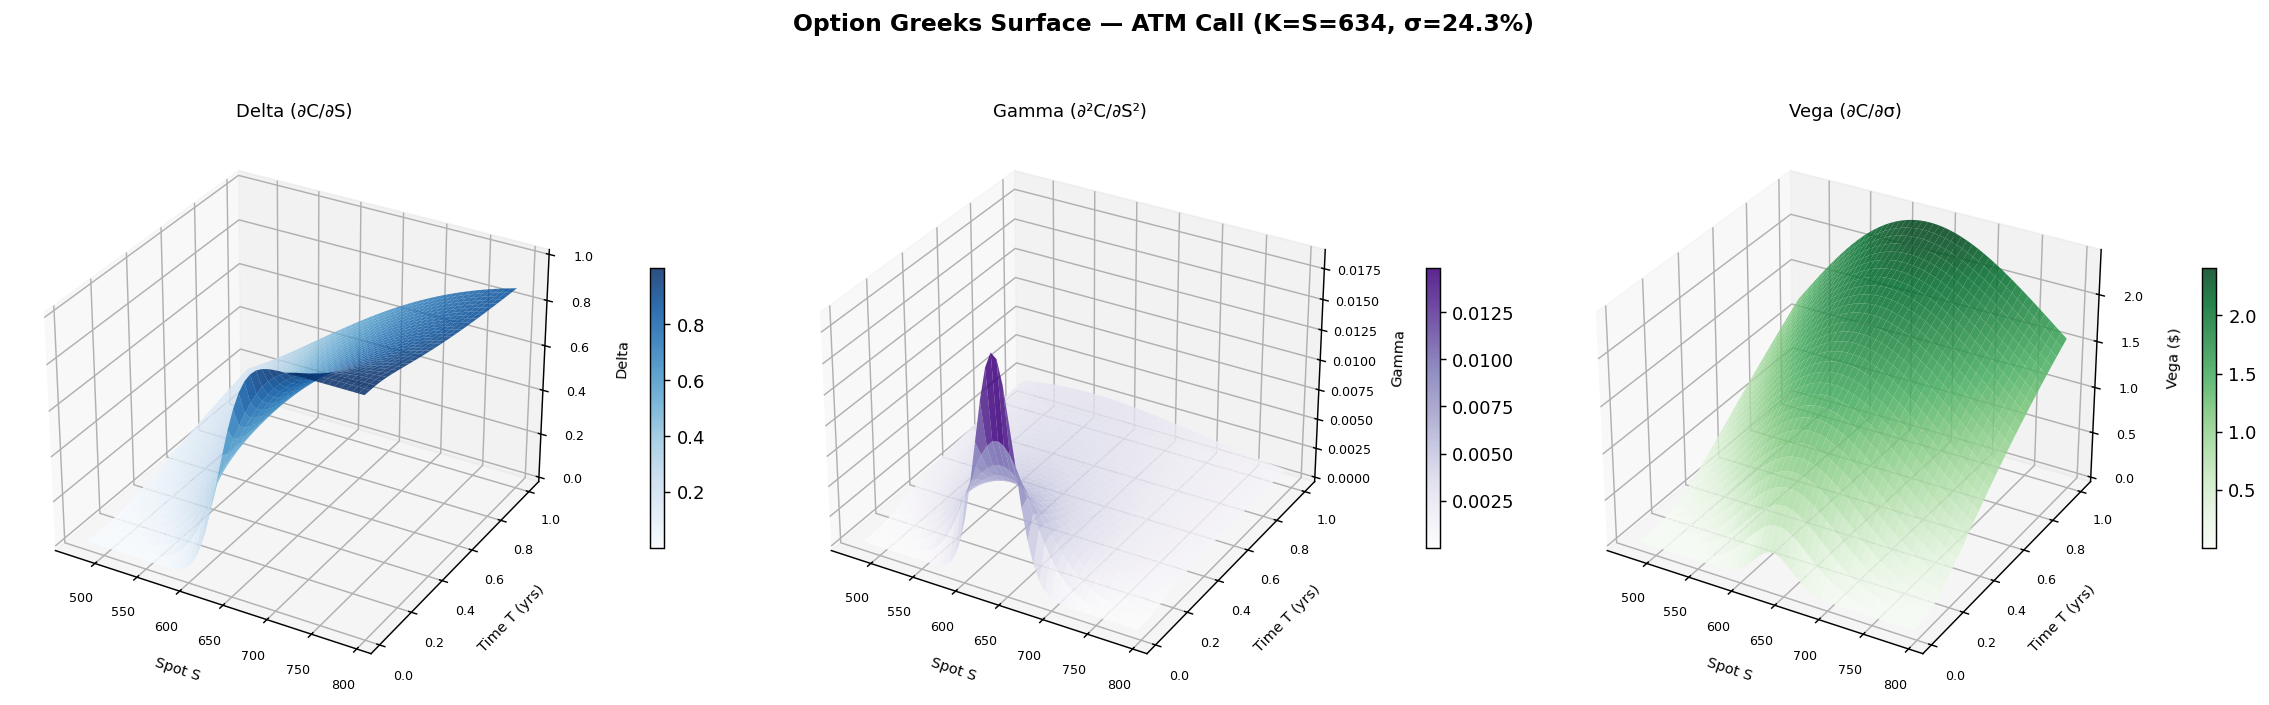

Plot 3 saved ✓


In [ ]:
# Most students plot Greeks vs S at fixed T.
# Plotting as a SURFACE over both S and T shows:
#   Delta surface: the probability surface — how "in the money" the option is
#                  across all spot levels and expiries simultaneously
#   Gamma surface: where the most convexity risk lives — peaks ATM, decays
#                  as option goes deep ITM/OTM or as T increases
# This is directly relevant to delta-hedging and risk management discussions.
# -----------------------------------------------------------------------------

S_range = np.linspace(S * 0.75, S * 1.25, 50)   # spot range ±25%
T_range = np.linspace(7/365, 1.0, 30)            # 1 week to 1 year
SS, TT  = np.meshgrid(S_range, T_range)

sigma_atm = cal_df[
    (cal_df["moneyness"] >= 0.98) &
    (cal_df["moneyness"] <= 1.02)
]["iv"].median()
print(f"ATM vol used for Greeks surface: {sigma_atm*100:.1f}%")

K_fixed = S   # strike fixed at current spot (ATM surface)

# Vectorized Greeks computation over the grid
D1 = (np.log(SS/K_fixed) + (r-q+0.5*sigma_atm**2)*TT) / (sigma_atm*np.sqrt(TT))
D2 = D1 - sigma_atm*np.sqrt(TT)

DELTA = np.exp(-q*TT) * norm.cdf(D1)
GAMMA = norm.pdf(D1) * np.exp(-q*TT) / (SS * sigma_atm * np.sqrt(TT))
VEGA  = SS * np.exp(-q*TT) * norm.pdf(D1) * np.sqrt(TT) / 100

fig = plt.figure(figsize=(18, 6))
fig.suptitle(f"Option Greeks Surface — ATM Call (K=S={S:.0f}, σ={sigma_atm*100:.1f}%)",
             fontsize=13, fontweight="bold")

greek_data = [
    ("Delta (∂C/∂S)",  DELTA, "Blues",   "Delta"),
    ("Gamma (∂²C/∂S²)", GAMMA, "Purples", "Gamma"),
    ("Vega (∂C/∂σ)",   VEGA,  "Greens",  "Vega ($)"),
]

for idx, (title, Z, cmap, zlabel) in enumerate(greek_data):
    ax = fig.add_subplot(1, 3, idx+1, projection="3d")
    surf = ax.plot_surface(SS, TT, Z, cmap=cmap, alpha=0.85,
                           linewidth=0, antialiased=True)
    ax.set_xlabel("Spot S",        labelpad=6, fontsize=8)
    ax.set_ylabel("Time T (yrs)",  labelpad=6, fontsize=8)
    ax.set_zlabel(zlabel,          labelpad=6, fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.tick_params(labelsize=7)
    fig.colorbar(surf, ax=ax, shrink=0.4, pad=0.1)

plt.tight_layout()
plt.savefig("plot3_greeks_surface.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 3 saved ✓")

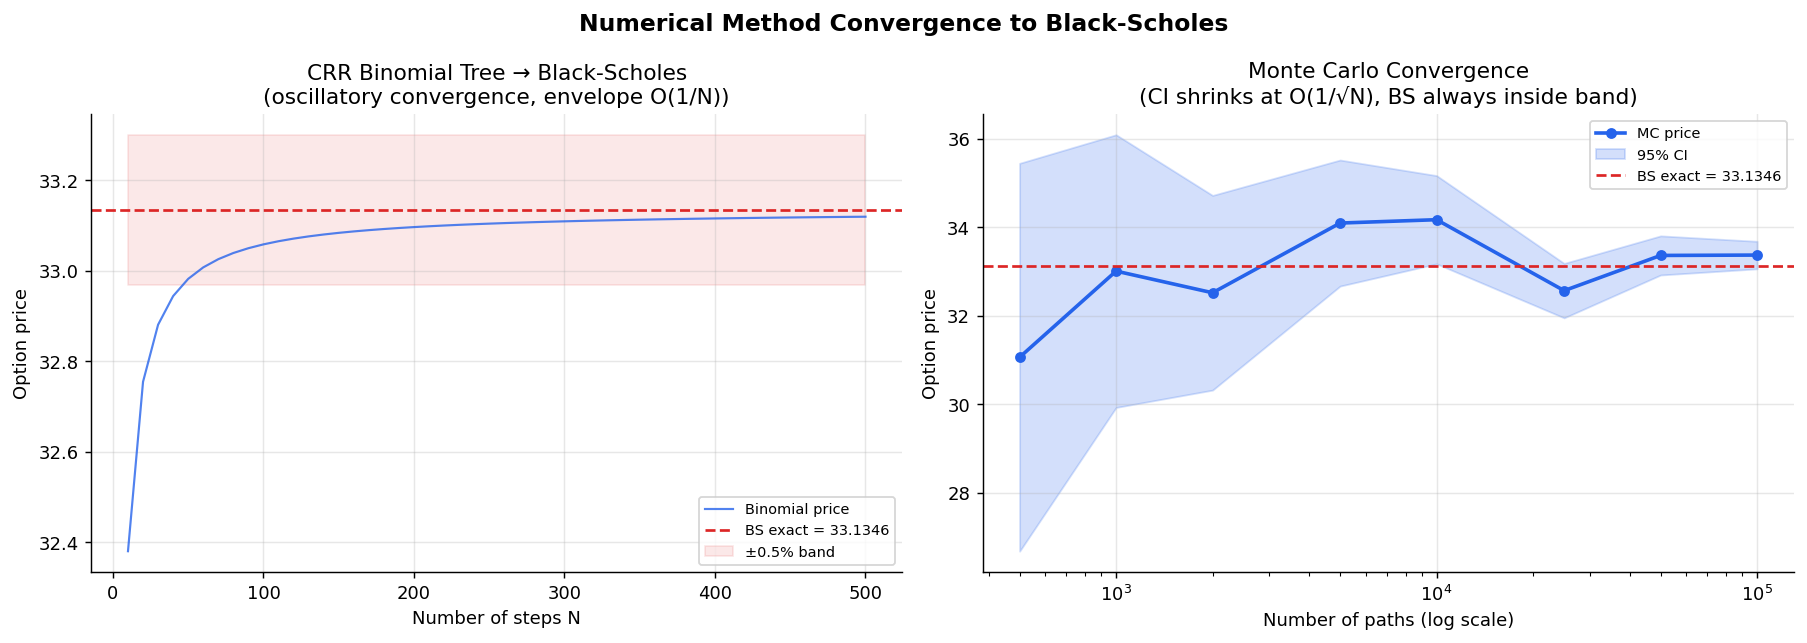

Plot 4 saved ✓


In [ ]:
# Two convergence results on one figure:
#   Left : Binomial tree price vs N steps → converges to BS
#          Shows oscillatory even/odd pattern tightening at O(1/N)
#   Right: MC price + 95% confidence interval vs N paths
#          Shows CI shrinking at O(1/√N), BS always inside the band
# -----------------------------------------------------------------------------

params_conv = dict(S=S, K=S, T=0.25, r=r, sigma=sigma_atm, q=q)
bs_ref      = bs_price(**params_conv, option_type="call")

# ── Binomial convergence ──
N_bin    = list(range(10, 501, 10))
bin_prices = [binomial_tree(**params_conv, N=N, option_type="call")
              for N in N_bin]

# ── MC convergence ──
N_mc_list  = [500, 1000, 2000, 5000, 10000, 25000, 50000, 100000]
mc_prices, mc_ses = [], []
rng = np.random.default_rng(42)

for N_paths in N_mc_list:
    dt    = params_conv["T"] / 252
    drift = (r - q - 0.5*sigma_atm**2)*dt
    diff  = sigma_atm*np.sqrt(dt)
    Z     = rng.standard_normal((N_paths, 252))
    S_T   = S * np.exp(np.sum(drift + diff*Z, axis=1))
    pays  = np.exp(-r*params_conv["T"]) * np.maximum(S_T - S, 0)
    mc_prices.append(pays.mean())
    mc_ses.append(pays.std()/np.sqrt(N_paths))

mc_prices = np.array(mc_prices)
mc_ses    = np.array(mc_ses)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Numerical Method Convergence to Black-Scholes",
             fontsize=13, fontweight="bold")

# Left: Binomial
ax = axes[0]
ax.plot(N_bin, bin_prices, lw=1.2, color=BLUE, alpha=0.8, label="Binomial price")
ax.axhline(bs_ref, color=RED, lw=1.5, ls="--",
           label=f"BS exact = {bs_ref:.4f}")
ax.fill_between(N_bin,
                [bs_ref*0.995]*len(N_bin),
                [bs_ref*1.005]*len(N_bin),
                alpha=0.1, color=RED, label="±0.5% band")
ax.set_xlabel("Number of steps N")
ax.set_ylabel("Option price")
ax.set_title("CRR Binomial Tree → Black-Scholes\n"
             "(oscillatory convergence, envelope O(1/N))")
ax.legend(fontsize=8)

# Right: MC
ax = axes[1]
ax.semilogx(N_mc_list, mc_prices, "o-", color=BLUE, lw=2, ms=5,
            label="MC price")
ax.fill_between(N_mc_list,
                mc_prices - 1.96*mc_ses,
                mc_prices + 1.96*mc_ses,
                alpha=0.2, color=BLUE, label="95% CI")
ax.axhline(bs_ref, color=RED, lw=1.5, ls="--",
           label=f"BS exact = {bs_ref:.4f}")
ax.set_xlabel("Number of paths (log scale)")
ax.set_ylabel("Option price")
ax.set_title("Monte Carlo Convergence\n"
             "(CI shrinks at O(1/√N), BS always inside band)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("plot4_convergence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 4 saved ✓")

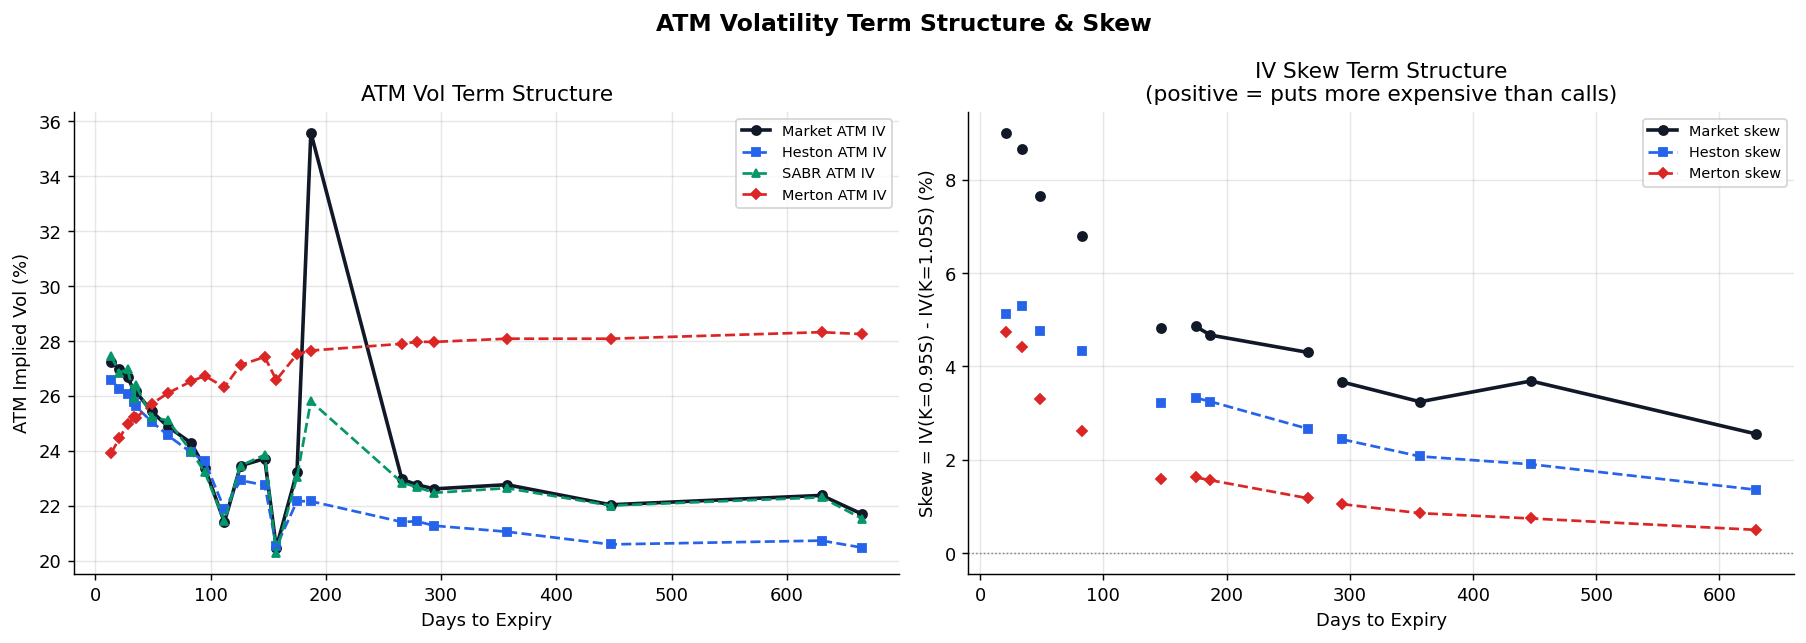

Plot 5 saved ✓


In [ ]:
# Two panels:
#   Left : ATM IV term structure — market vs Heston vs SABR
#          Shows how well each model captures vol term structure
#   Right: Skew (25-delta put IV minus 25-delta call IV) by expiry
#          A key risk metric — shows how skew evolves with tenor

atm_data = []
for exp in sorted(cal_df["expiry"].unique()):
    sub   = cal_df[cal_df["expiry"] == exp]
    T_val = sub["T"].iloc[0]
    m     = sub["moneyness"]

    atm_row = sub.iloc[(m - 1.0).abs().argsort()[:3]]
    iv_mkt  = atm_row["iv"].mean()
    iv_hes  = atm_row["iv_heston"].mean()
    iv_sab  = atm_row["iv_sabr"].mean()
    iv_mer  = atm_row["iv_merton"].mean()

    # Skew: OTM put (m=0.95) minus OTM call (m=1.05)
    put_side  = sub[(m >= 0.93) & (m <= 0.97)]["iv"].mean()
    call_side = sub[(m >= 1.03) & (m <= 1.07)]["iv"].mean()
    skew_mkt  = put_side - call_side if not np.isnan(put_side+call_side) else np.nan

    put_h  = sub[(m >= 0.93) & (m <= 0.97)]["iv_heston"].mean()
    call_h = sub[(m >= 1.03) & (m <= 1.07)]["iv_heston"].mean()
    skew_h = put_h - call_h if not np.isnan(put_h+call_h) else np.nan

    put_mer  = sub[(m >= 0.93) & (m <= 0.97)]["iv_merton"].mean()
    call_mer = sub[(m >= 1.03) & (m <= 1.07)]["iv_merton"].mean()
    skew_mer = put_mer - call_mer if not np.isnan(put_mer+call_mer) else np.nan

    atm_data.append({"expiry": exp, "T": T_val,
                     "atm_mkt": iv_mkt, "atm_hes": iv_hes,
                     "atm_sab": iv_sab, "atm_mer": iv_mer,
                     "skew_mkt": skew_mkt, "skew_hes": skew_h,
                     "skew_mer": skew_mer})

atm_df = pd.DataFrame(atm_data).sort_values("T")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ATM Volatility Term Structure & Skew", fontsize=13,
             fontweight="bold")

# Left: ATM term structure
ax = axes[0]
ax.plot(atm_df["T"]*365, atm_df["atm_mkt"]*100, "o-",
        color=BLACK, lw=2, ms=5, label="Market ATM IV")
ax.plot(atm_df["T"]*365, atm_df["atm_hes"]*100, "s--",
        color=BLUE, lw=1.5, ms=4, label="Heston ATM IV")
ax.plot(atm_df["T"]*365, atm_df["atm_sab"]*100, "^--",
        color=GREEN, lw=1.5, ms=4, label="SABR ATM IV")
ax.plot(atm_df["T"]*365, atm_df["atm_mer"]*100, "D--",
        color=RED, lw=1.5, ms=4, label="Merton ATM IV")
ax.set_xlabel("Days to Expiry")
ax.set_ylabel("ATM Implied Vol (%)")
ax.set_title("ATM Vol Term Structure")
ax.legend(fontsize=8)

# Right: Skew term structure
ax = axes[1]
ax.plot(atm_df["T"]*365, atm_df["skew_mkt"]*100, "o-",
        color=BLACK, lw=2, ms=5, label="Market skew")
ax.plot(atm_df["T"]*365, atm_df["skew_hes"]*100, "s--",
        color=BLUE, lw=1.5, ms=4, label="Heston skew")
ax.plot(atm_df["T"]*365, atm_df["skew_mer"]*100, "D--",
        color=RED, lw=1.5, ms=4, label="Merton skew")
ax.axhline(0, color="gray", ls=":", lw=0.8)
ax.set_xlabel("Days to Expiry")
ax.set_ylabel("Skew = IV(K=0.95S) - IV(K=1.05S) (%)")
ax.set_title("IV Skew Term Structure\n"
             "(positive = puts more expensive than calls)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("plot5_term_structure.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 5 saved ✓")

In [ ]:
print("\n" + "="*65)
print("PHASE 7 — FINAL PROJECT SUMMARY")
print("="*65)

print(f"\nMarket snapshot : SPY on {snapshot_date}")
print(f"Spot price      : ${S:.2f}")
print(f"Risk-free rate  : {r*100:.3f}%")
print(f"Dividend yield  : {q*100:.2f}%")
print(f"Contracts used  : {len(cal_df):,}")

print("\nModel fit (RMSE vs market IV):")
for col, label in [("iv_heston","Heston"), ("iv_sabr","SABR"),
                   ("iv_merton","Merton")]:
    err  = (cal_df[col] - cal_df["iv"]).dropna()
    rmse = np.sqrt((err**2).mean())*100
    mae  = err.abs().mean()*100
    n    = len(err)
    print(f"  {label:<8}: RMSE={rmse:.2f}%  MAE={mae:.2f}%  n={n}")

print("\nOutputs saved:")
for f in ["plot1_iv_surface.png", "plot2_smile_overlay.png",
          "plot3_greeks_surface.png", "plot4_convergence.png",
          "plot5_term_structure.png"]:
    exists = "✓" if os.path.exists(f) else "✗"
    print(f"  {exists} {f}")

print("\n" + "="*65)
print("PROJECT COMPLETE — all 7 phases built.")
print("="*65)

print("""
PHASES BUILT:
  Phase 1 — Black-Scholes + Greeks (analytical)
  Phase 2 — Market data pipeline (SPY option chain)
  Phase 3 — Binomial Tree + Monte Carlo
  Phase 4 — Finite Difference (Explicit, Implicit, Crank-Nicolson)
  Phase 5 — Heston + Merton + SABR stochastic models
  Phase 6 — Model calibration to market data
  Phase 7 — Visualization & final demo notebook

MODELS IMPLEMENTED:
  Pricing  : Black-Scholes, Binomial CRR, Monte Carlo GBM,
             Finite Difference (3 schemes), Heston CF,
             Merton Jump Diffusion, SABR
  Exotics  : Asian (arithmetic), Barrier (knock-in/out)
  Greeks   : Delta, Gamma, Vega, Theta, Rho (analytical + surface)
  Numerics : Newton-Raphson IV, Brent IV, Cholesky correlation,
             Euler-Maruyama SDE, Thomas algorithm tridiagonal solve,
             Gil-Pelaez / Lewis Fourier inversion
""")


PHASE 7 — FINAL PROJECT SUMMARY

Market snapshot : SPY on 2026-03-27
Spot price      : $634.09
Risk-free rate  : 4.300%
Dividend yield  : 1.06%
Contracts used  : 960

Model fit (RMSE vs market IV):
  Heston  : RMSE=1.89%  MAE=1.42%  n=960
  SABR    : RMSE=0.97%  MAE=0.34%  n=960
  Merton  : RMSE=5.80%  MAE=5.00%  n=960

Outputs saved:
  ✓ plot1_iv_surface.png
  ✓ plot2_smile_overlay.png
  ✓ plot3_greeks_surface.png
  ✓ plot4_convergence.png
  ✓ plot5_term_structure.png

PROJECT COMPLETE — all 7 phases built.

PHASES BUILT:
  Phase 1 — Black-Scholes + Greeks (analytical)
  Phase 2 — Market data pipeline (SPY option chain)
  Phase 3 — Binomial Tree + Monte Carlo
  Phase 4 — Finite Difference (Explicit, Implicit, Crank-Nicolson)
  Phase 5 — Heston + Merton + SABR stochastic models
  Phase 6 — Model calibration to market data
  Phase 7 — Visualization & final demo notebook

MODELS IMPLEMENTED:
  Pricing  : Black-Scholes, Binomial CRR, Monte Carlo GBM,
             Finite Difference (3 sch